In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")

import re
import nltk
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, make_scorer

from time import time
import pickle


In [26]:
df = pd.read_csv("Bangla_Corpus.csv")
df.head()


,Unnamed: 0,text,label,target
0,0,অবিশ^াস্য কিন্তু সত্য। প্রাচীনকালে হিন্দু মালা...,Hateful,1
1,1,"আজ বিশ^ হাড়কিপটা দিবস, উইশ করুন আপনার সেই কিপ্...",Neutral,0
2,2,চীনকে চিনে নিতে ৭২ ঘন্টা সময় চায় ভারত।,Hateful,1
3,3,"আমারে নিবা মাঝি লগে? ব্রীজ হইছে, ব্রীজ দিয়া যা।",Neutral,0
4,4,বাম আর নাস্তিক আজ আওয়ামীলীগের পিঠে সওয়ার হয়েছে।,Hateful,1


In [27]:
def map_labels(df):
    mapping_dict = {
        'Hateful': 1,
        'Neutral': 0,
        'Like': 0,  # adjust as needed
    }
    df['label'] = df['label'].map(mapping_dict).fillna(df['label']).astype(int)
    return df

df = map_labels(df)
print("Unique labels after mapping:", df['label'].unique())


Unique labels after mapping: [1 0]


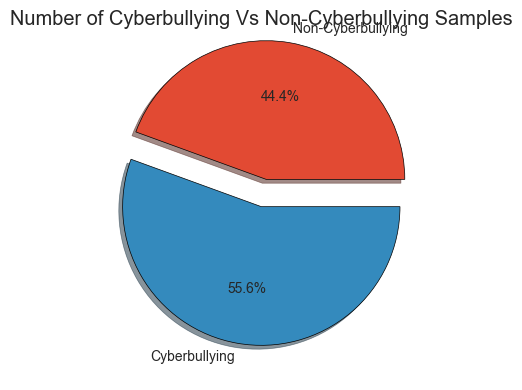

In [28]:
def performdatadistribution(df):
    total = df.shape[0]
    num_non_toxic = df[df['label']==0].shape[0]
    
    slices = [num_non_toxic/total, (total-num_non_toxic)/total]
    labeling = ['Non-Cyberbullying', 'Cyberbullying']
    explode = [0.2, 0]
    
    plt.figure(figsize=(4,4))
    plt.pie(slices, explode=explode, shadow=True, autopct="%1.1f%%", labels=labeling, wedgeprops={'edgecolor': 'black'})
    plt.title('Number of Cyberbullying Vs Non-Cyberbullying Samples')
    plt.tight_layout()
    plt.show()

performdatadistribution(df)


In [29]:
def remove_pattern(input_txt, pattern):
    if type(input_txt) == str:
        r = re.findall(pattern, input_txt)
        for i in r:
            input_txt = re.sub(i, '', input_txt)
        return input_txt
    else:
        return ""

def bangla_text_cleaning(text):
    if type(text) != str:
        return ""
    # Remove English letters and digits (including Bangla digits)
    text = re.sub(r'[a-zA-Z0-9০-৯]', ' ', text)
    # Keep only Bangla characters & space (approximate Unicode range)
    text = re.sub(r'[^অ-ঔক-রৎ-ড়ঢ়-য়\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def datasetCleaning(df):
    df['length_text'] = df['text'].str.len()
    combined_df = pd.concat([df, df], ignore_index=True)  # duplicate dataset if needed
    
    combined_df['tidy_tweet'] = np.vectorize(remove_pattern)(combined_df['text'], "@[\w]*")
    combined_df['tidy_tweet'] = combined_df['tidy_tweet'].apply(bangla_text_cleaning)
    combined_df['tidy_tweet'] = combined_df['tidy_tweet'].apply(lambda x: ' '.join([w for w in x.split() if len(w) > 1]))
    combined_df['length_tidy_tweet'] = combined_df['tidy_tweet'].str.len()
    
    return combined_df, df

combined_df, df = datasetCleaning(df)
combined_df.head()


,Unnamed: 0,text,label,target,length_text,tidy_tweet,length_tidy_tweet
0,0,অবিশ^াস্য কিন্তু সত্য। প্রাচীনকালে হিন্দু মালা...,1,1,63,অব নক উনর,9
1,1,"আজ বিশ^ হাড়কিপটা দিবস, উইশ করুন আপনার সেই কিপ্...",0,0,58,আজ ড়ক পট উই কর আপন বন,21
2,2,চীনকে চিনে নিতে ৭২ ঘন্টা সময় চায় ভারত।,1,1,39,নক ঘন ময় রত,11
3,3,"আমারে নিবা মাঝি লগে? ব্রীজ হইছে, ব্রীজ দিয়া যা।",0,0,49,আম ইছ,5
4,4,বাম আর নাস্তিক আজ আওয়ামীলীগের পিঠে সওয়ার হয়েছে।,1,1,48,আর আজ আওয় ওয়,12


In [30]:
def performdatasplit(x, y, combined_df, df):
    X_train, X_test, y_train, y_test = train_test_split(combined_df['tidy_tweet'], combined_df['label'], test_size=x, random_state=y)
    print(f"Number of rows in total dataset: {combined_df.shape[0]}")
    print(f"Train dataset rows: {X_train.shape[0]}")
    print(f"Test dataset rows: {X_test.shape[0]}")

    # Load Bangla stopwords from CSV
    try:
        stopwords_df = pd.read_csv('bangla_stopwords.csv', header=None, encoding='utf-8')
        content_list = stopwords_df[0].tolist()
        print(f"Loaded {len(content_list)} Bangla stopwords.")
    except Exception as e:
        print(f"Error loading stopwords CSV: {e}")
        content_list = None

    tfidfvector = TfidfVectorizer(stop_words=content_list, lowercase=True) if content_list else TfidfVectorizer(lowercase=True)

    training_data = tfidfvector.fit_transform(X_train.values.astype('U'))
    testing_data = tfidfvector.transform(X_test.values.astype('U'))

    # Save the entire fitted TF-IDF vectorizer (not just vocabulary)
    pickle.dump(tfidfvector, open('tfidfvector.pkl', 'wb'))

    return X_train, X_test, y_train, y_test, testing_data, 'tfidfvector.pkl', training_data, content_list

X_train, X_test, y_train, y_test, testing_data, filename, training_data, content_list = performdatasplit(0.2, 42, combined_df, df)


Number of rows in total dataset: 9000
Train dataset rows: 7200
Test dataset rows: 1800
Loaded 112 Bangla stopwords.


C:\Users\samis\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['অথব', 'অন', 'অবশ', 'আগ', 'আছ', 'আদ', 'আপন', 'আব', 'আম', 'আমর', 'আস', 'উন', 'এইজন', 'একট', 'এট', 'এব', 'ওয', 'ওয়', 'কর', 'করছ', 'করত', 'করল', 'জন', 'তব', 'পর', 'বল', 'যদ', 'রক', 'রণ', 'রত', 'হইব', 'হত', 'হব', 'হয', 'হয়ত'] not in stop_words.
  warnings.warn(


In [31]:
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier

def pipeline(X_train, y_train, X_test, y_test):
    MODELS = [LinearSVC(), LogisticRegression(max_iter=500), MultinomialNB(), DecisionTreeClassifier(),
              AdaBoostClassifier(), BaggingClassifier(), SGDClassifier(max_iter=1000)]
    
    final_result = []
    for model in MODELS:
        results = {}
        results['Algorithm'] = model.__class__.__name__

        start = time()
        print(f"Training Time : {model.__class__.__name__}")
        model.fit(X_train, y_train)
        end = time()
        results['Training Time'] = end - start

        filename = model.__class__.__name__ + ".pkl"
        pickle.dump(model, open(filename, "wb"))

        start = time()
        prediction_test = model.predict(X_test)
        prediction_train = model.predict(X_train)
        end = time()
        results['Prediction Time'] = end - start

        results['Accuracy : Test'] = accuracy_score(y_test, prediction_test)
        results['Accuracy : Train'] = accuracy_score(y_train, prediction_train)

        results['F1 Score : Test'] = f1_score(y_test, prediction_test)
        results['F1 Score : Train'] = f1_score(y_train, prediction_train)

        results['Precision : Test'] = precision_score(y_test, prediction_test)
        results['Precision : Train'] = precision_score(y_train, prediction_train)

        results['Recall : Test'] = recall_score(y_test, prediction_test)
        results['Recall : Train'] = recall_score(y_train, prediction_train)

        print(f"Training {model.__class__.__name__} finished in {results['Training Time']} sec")
        final_result.append(results.copy())

    return final_result

final_result = pipeline(training_data, y_train, testing_data, y_test)


Training Time : LinearSVC
Training LinearSVC finished in 0.018010854721069336 sec
Training Time : LogisticRegression
Training LogisticRegression finished in 0.009514331817626953 sec
Training Time : MultinomialNB
Training MultinomialNB finished in 0.002104520797729492 sec
Training Time : DecisionTreeClassifier
Training DecisionTreeClassifier finished in 0.2302703857421875 sec
Training Time : AdaBoostClassifier
Training AdaBoostClassifier finished in 0.23673582077026367 sec
Training Time : BaggingClassifier
Training BaggingClassifier finished in 2.130819797515869 sec
Training Time : SGDClassifier
Training SGDClassifier finished in 0.010015487670898438 sec


In [32]:
def performfinalresult(final_results):
    results = pd.DataFrame(final_results)
    results = results.reindex(columns=['Algorithm', 'Accuracy : Test', 'Precision : Test', 'Recall : Test', 'F1 Score : Test', 'Prediction Time',
                                       'Accuracy : Train', 'Precision : Train', 'Recall : Train', 'F1 Score : Train', 'Training Time'])
    results.sort_values(by='F1 Score : Test', inplace=True, ascending=False)
    return results

results = performfinalresult(final_result)
results.reset_index(drop=True, inplace=True)
results


,Algorithm,Accuracy : Test,Precision : Test,Recall : Test,F1 Score : Test,Prediction Time,Accuracy : Train,Precision : Train,Recall : Train,F1 Score : Train,Training Time
0,DecisionTreeClassifier,0.908333,0.919028,0.914401,0.916709,0.004000,0.967083,0.967278,0.973796,0.970526,0.230270
1,BaggingClassifier,0.891667,0.914761,0.886203,0.900256,0.032075,0.962639,0.962853,0.970302,0.966563,2.130820
2,LinearSVC,0.767778,0.795478,0.779456,0.787386,0.000993,0.806111,0.834315,0.813077,0.823559,0.018011
3,SGDClassifier,0.755000,0.777666,0.778449,0.778057,0.001004,0.797361,0.821880,0.811829,0.816824,0.010015
4,LogisticRegression,0.743889,0.758755,0.785498,0.771895,0.000995,0.781528,0.799606,0.810581,0.805056,0.009514
5,MultinomialNB,0.744444,0.767302,0.770393,0.768844,0.001007,0.774444,0.792968,0.804842,0.798861,0.002105
6,AdaBoostClassifier,0.631667,0.620791,0.853978,0.718949,0.032494,0.637361,0.625179,0.869978,0.727538,0.236736


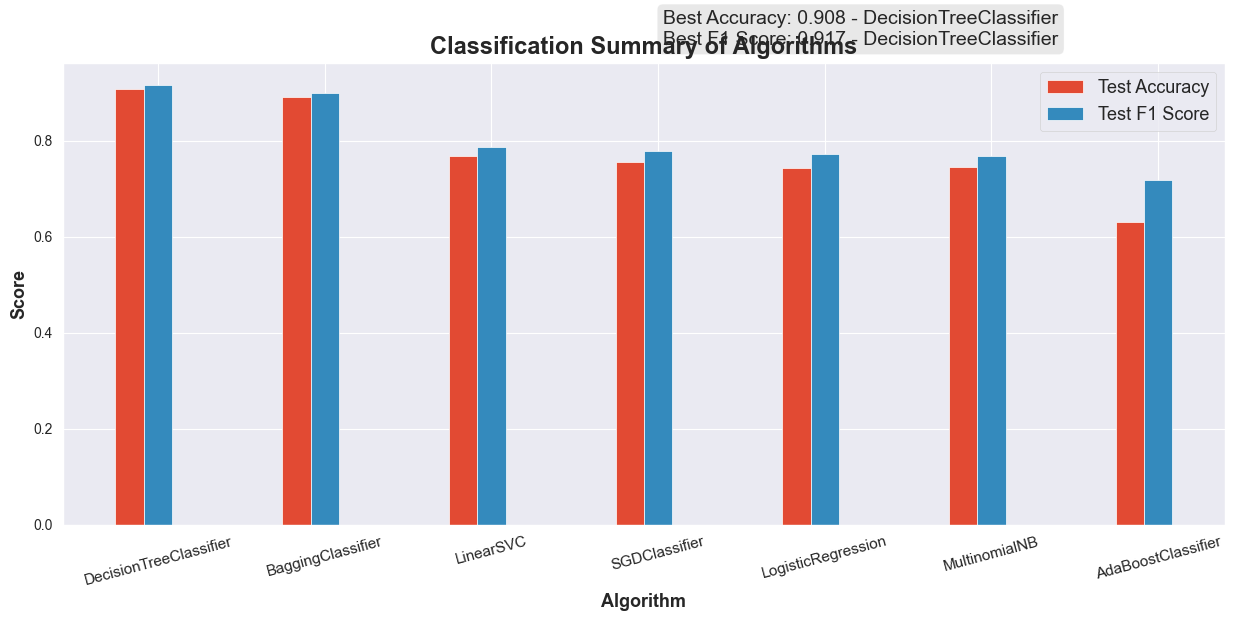

In [33]:
import numpy as np

best_acc = results[results['Accuracy : Test'] == results['Accuracy : Test'].max()]
best_f1 = results[results['F1 Score : Test'] == results['F1 Score : Test'].max()]

sns.set_style('darkgrid')
plt.figure(figsize=(15, 6))

barWidth = 0.17
bars1 = results['Accuracy : Test']
bars2 = results['F1 Score : Test']

r1 = np.arange(len(bars1))
r2 = [x + barWidth for x in r1]

pal = sns.color_palette()
plt.bar(r1, bars1, color=pal[0], width=barWidth, edgecolor='white', label='Test Accuracy')
plt.bar(r2, bars2, color=pal[1], width=barWidth, edgecolor='white', label='Test F1 Score')

plt.xlabel('Algorithm', fontweight='bold', fontsize=13)
plt.ylabel('Score', fontweight='bold', fontsize=13)
plt.xticks([r + barWidth for r in range(len(bars1))], results['Algorithm'], rotation=15, fontsize=11)

plt.legend(fontsize=13)

textstr = '\n'.join([
    f'Best Accuracy: {best_acc["Accuracy : Test"].values[0]:.3f} - {best_acc["Algorithm"].values[0]}',
    f'Best F1 Score: {best_f1["F1 Score : Test"].values[0]:.3f} - {best_f1["Algorithm"].values[0]}'
])
props = dict(boxstyle='round', facecolor='lightgrey', alpha=0.5)

plt.title('Classification Summary of Algorithms', fontweight='bold', fontsize=17)
plt.text(3.2, 1.0, textstr, fontsize=14, bbox=props)
plt.show()


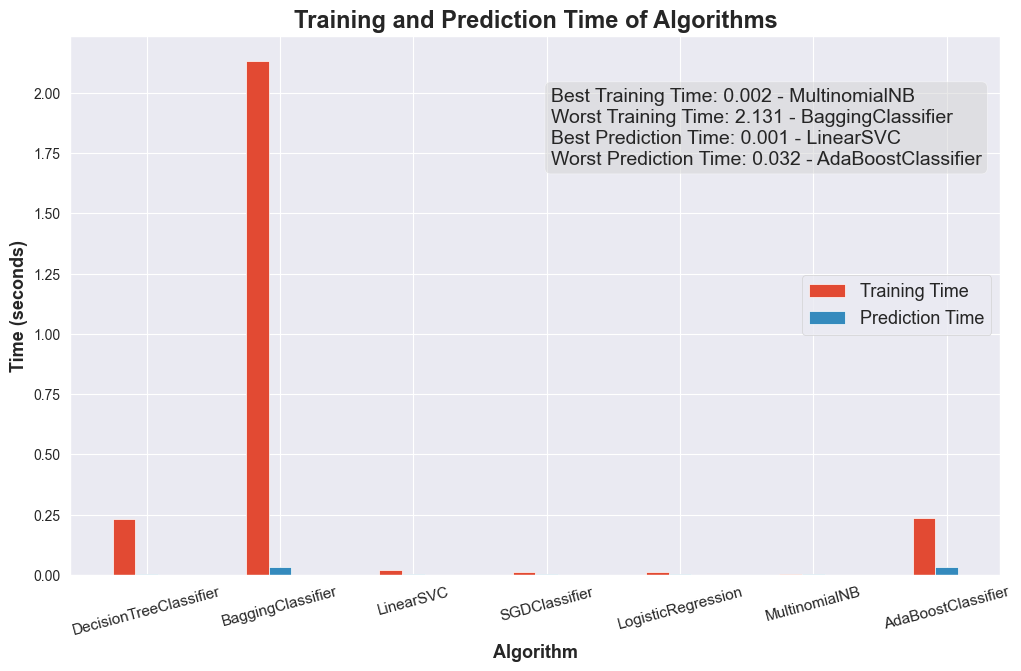

In [34]:
best_train_time = results[results['Training Time'] == results['Training Time'].min()]
worst_train_time = results[results['Training Time'] == results['Training Time'].max()]
best_prediction_time = results[results['Prediction Time'] == results['Prediction Time'].min()]
worst_prediction_time = results[results['Prediction Time'] == results['Prediction Time'].max()]

plt.figure(figsize=(12, 7))
barWidth = 0.17
bars1 = results['Training Time']
bars2 = results['Prediction Time']

r1 = np.arange(len(bars1))
r2 = [x + barWidth for x in r1]

plt.bar(r1, bars1, color=pal[0], width=barWidth, edgecolor='white', label='Training Time')
plt.bar(r2, bars2, color=pal[1], width=barWidth, edgecolor='white', label='Prediction Time')

plt.xlabel('Algorithm', fontweight='bold', fontsize=13)
plt.ylabel('Time (seconds)', fontweight='bold', fontsize=13)
plt.xticks([r + barWidth for r in range(len(bars1))], results['Algorithm'], rotation=15, fontsize=11)

textstr = '\n'.join([
    f'Best Training Time: {best_train_time["Training Time"].values[0]:.3f} - {best_train_time["Algorithm"].values[0]}',
    f'Worst Training Time: {worst_train_time["Training Time"].values[0]:.3f} - {worst_train_time["Algorithm"].values[0]}',
    f'Best Prediction Time: {best_prediction_time["Prediction Time"].values[0]:.3f} - {best_prediction_time["Algorithm"].values[0]}',
    f'Worst Prediction Time: {worst_prediction_time["Prediction Time"].values[0]:.3f} - {worst_prediction_time["Algorithm"].values[0]}'
])
props = dict(boxstyle='round', facecolor='lightgrey', alpha=0.5)

plt.text(3.2, max(bars1)*0.8, textstr, fontsize=14, bbox=props)
plt.legend(fontsize=13)
plt.title('Training and Prediction Time of Algorithms', fontweight='bold', fontsize=17)
plt.show()


In [46]:
data = ["আমি কাল সকালে ভাত খেয়েছি"]

# Load entire fitted vectorizer
tfidf_vector = pickle.load(open("tfidfvector.pkl", "rb"))

preprocessed_data = tfidf_vector.transform(data)

# Load trained model (example LinearSVC)
trained_model = pickle.load(open('LinearSVC.pkl', 'rb'))

predictions = trained_model.predict(preprocessed_data)

for i, pred in enumerate(predictions):
    print(f"Text: {data[i]}")
    if pred == 1:
        print("Prediction: Cyberbullying")
    else:
        print("Prediction: Non-Cyberbullying")


Text: আমি কাল সকালে ভাত খেয়েছি
Prediction: Non-Cyberbullying


In [36]:
from sklearn.model_selection import GridSearchCV

def tuining(clf, param_dict, X_train, y_train, X_test, y_test):
    scorer = make_scorer(f1_score)
    grid_obj = GridSearchCV(estimator=clf, param_grid=param_dict, scoring=scorer, cv=5)
    grid_fit = grid_obj.fit(X_train, y_train)
    best_clf = grid_fit.best_estimator_
    best_prediction = best_clf.predict(X_test)

    print(clf.__class__.__name__)
    print(f"Best Parameter:  {grid_fit.best_params_}")
    
    print(f"Accuracy:  {accuracy_score(y_test, best_prediction)}")
    print(f"F1 Score :  {f1_score(y_test, best_prediction)}")
    print(f"Precision :  {precision_score(y_test, best_prediction)}")
    print(f"Recall:  {recall_score(y_test, best_prediction)}")

param_grid = {
    'C': [0.25, 0.5, 0.75, 1, 1.2]
}

clf_model = LinearSVC(max_iter=10000)

tuining(clf_model, param_grid, training_data, y_train, testing_data, y_test)

pickle.dump(clf_model, open("LinearSVCTuned.pkl", "wb"))


LinearSVC
Best Parameter:  {'C': 0.25}
Accuracy:  0.7622222222222222
F1 Score :  0.7849246231155779
Precision :  0.7833500501504513
Recall:  0.7865055387713998
